In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [1]:
# Load data, display first few rows
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/mental_health_tech_ml.csv")

df_ml.head()

,Age,self_employed,family_history,treatment,remote_work,tech_company,obs_consequence,Age__missing,Gender__missing,self_employed__missing,work_interfere__missing,Gender_female,Gender_male,work_interfere_Never,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,no_employees_1-5,no_employees_100-500,no_employees_26-100,no_employees_500-1000,no_employees_6-25,no_employees_More than 1000,benefits_Don't know,benefits_No,benefits_Yes,care_options_No,care_options_Not sure,care_options_Yes,wellness_program_Don't know,wellness_program_No,wellness_program_Yes,seek_help_Don't know,seek_help_No,seek_help_Yes,anonymity_Don't know,anonymity_No,anonymity_Yes,leave_Don't know,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_Maybe,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_Maybe,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_No,coworkers_Some of them,coworkers_Yes,supervisor_No,supervisor_Some of them,supervisor_Yes,mental_health_interview_Maybe,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_Maybe,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_Don't know,mental_vs_physical_No,mental_vs_physical_Yes
0,37.0,0.0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0,1
1,44.0,0.0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0
2,32.0,0.0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0
3,31.0,0.0,1,1,0,1,1,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0
4,31.0,0.0,0,0,1,1,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,1,0,0


In [2]:
# Target variable: work interference + treatment
# Exclude rows where the original target-defining variables were missing
df = df_ml.copy()

# Keep only rows with observed work_interfere and treatment
if "work_interfere__missing" in df.columns:
    df = df[df["work_interfere__missing"] == 0].copy()

if "treatment__missing" in df.columns:
    df = df[df["treatment__missing"] == 0].copy()

# Create binary work interference variable
# 0 = Never
# 1 = Rarely / Sometimes / Often
df["work_interfere_binary"] = (
    df[[
        "work_interfere_Rarely",
        "work_interfere_Sometimes",
        "work_interfere_Often"
    ]].sum(axis=1) > 0
).astype(int)

# Create combined target variable:
# 0 = no interference
# 1 = interference but no treatment
# 2 = interference + treatment
df["combined_target"] = np.select(
    [
        df["work_interfere_Never"] == 1,
        (df["work_interfere_binary"] == 1) & (df["treatment"] == 0),
        (df["work_interfere_binary"] == 1) & (df["treatment"] == 1),
    ],
    [0, 1, 2],
    default=np.nan
)

# Drop any rows that still do not have a valid target
df = df.dropna(subset=["combined_target"]).copy()
df["combined_target"] = df["combined_target"].astype(int)

# Define predictors and target
# Remove:
# - target variable
# - target-defining variables (to avoid leakage)
# - missingness indicators for target-defining variables
X = df.drop(columns=[
    "combined_target",
    "treatment",
    "work_interfere_Never",
    "work_interfere_Rarely",
    "work_interfere_Sometimes",
    "work_interfere_Often",
    "work_interfere__missing",
    "work_interfere_binary",
    "treatment__missing"
], errors="ignore")

y = df["combined_target"]

# Check final class distribution
print(y.value_counts())
print(y.value_counts(normalize=True))
print(X.shape, y.shape)

combined_target
2    603
0    213
1    179
Name: count, dtype: int64
combined_target
2    0.606030
0    0.214070
1    0.179899
Name: proportion, dtype: float64
(995, 58) (995,)


In [3]:
# Should be 0
print(df["combined_target"].isna().sum())

# Every row must belong to exactly one class
print(df["combined_target"].value_counts().sum(), len(df))

0
995 995


In [4]:
# Result means:
# 21.4% employees have no work interference (class 0), meaning they do not experience mental health issues that interfere with work.
# 60% employees have work interference and seek treatment (class 2)
# 18% employees experience work interference but do not seek treatment (class 1)
df["combined_target"].value_counts(normalize=True)

combined_target
2    0.606030
0    0.214070
1    0.179899
Name: proportion, dtype: float64

In [5]:
# Import function to split dataset into training and testing subsets
from sklearn.model_selection import train_test_split

# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Split data into training and test sets
# - 80% training, 20% testing
# - stratify=y ensures class distribution is preserved in both sets
# - random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Initialize Logistic Regression model
# - solver="lbfgs" is suitable for small/medium datasets
# - max_iter increased to ensure convergence
# - class_weight="balanced" handles class imbalance
# - random_state ensures reproducibility
logreg = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

# Train the model on the training data
logreg.fit(X_train, y_train)

# Generate predicted class labels for the test set
y_pred = logreg.predict(X_test)

# Generate predicted class probabilities for the test set
# (used for metrics like ROC-AUC, calibration, etc.)
y_prob = logreg.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.46      0.60      0.52        43
           1       0.30      0.50      0.38        36
           2       0.83      0.57      0.67       120

    accuracy                           0.56       199
   macro avg       0.53      0.56      0.52       199
weighted avg       0.65      0.56      0.59       199

Macro F1: 0.5227557755775578
Weighted F1: 0.5861913528036221


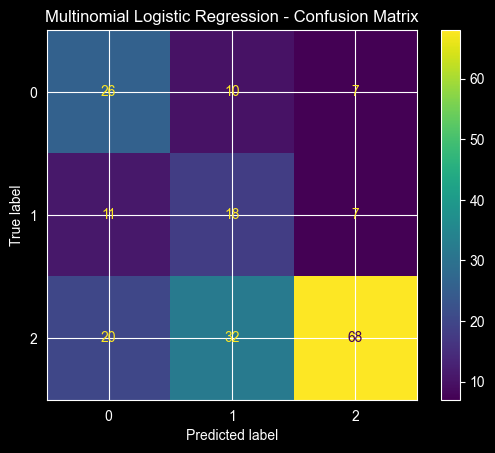

In [6]:
# Evaluation
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Classification report
print(classification_report(y_test, y_pred))

# F1-score
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Multinomial Logistic Regression - Confusion Matrix")
plt.show()

In [7]:
# Import Random Forest classifier (ensemble tree-based model)
from sklearn.ensemble import RandomForestClassifier

# Import function to split dataset into training and testing subsets
from sklearn.model_selection import train_test_split

# Split data into training and test sets
# - 80% training, 20% testing
# - stratify=y preserves class distribution (important for imbalanced data)
# - random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Initialize Random Forest model
# - n_estimators: number of trees in the forest (higher → more stable but slower)
# - max_depth=None: trees grow fully unless constrained
# - min_samples_split: minimum samples required to split a node (controls overfitting)
# - min_samples_leaf: minimum samples in a leaf node (smooths predictions)
# - class_weight="balanced": adjusts for class imbalance
# - random_state: ensures reproducibility
# - n_jobs=-1: use all available CPU cores for faster training
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train the Random Forest model on the training data
rf.fit(X_train, y_train)

# Generate predicted class labels for the test set
y_pred_rf = rf.predict(X_test)

# Generate predicted class probabilities for the test set
# (useful for ROC-AUC, calibration plots, threshold tuning, etc.)
y_prob_rf = rf.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.46      0.42      0.44        43
           1       0.40      0.22      0.29        36
           2       0.72      0.84      0.78       120

    accuracy                           0.64       199
   macro avg       0.53      0.49      0.50       199
weighted avg       0.61      0.64      0.62       199

Random Forest Macro F1: 0.5005539176270885
Random Forest Weighted F1: 0.6150479009898057


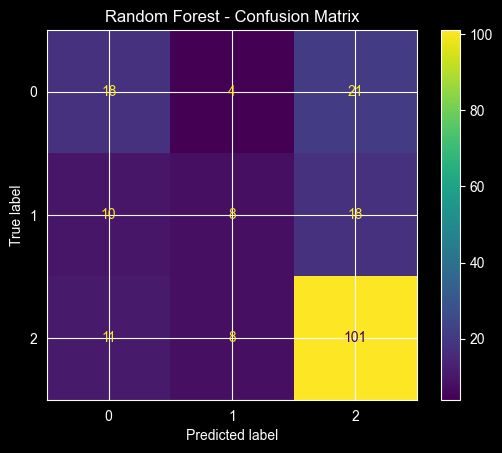

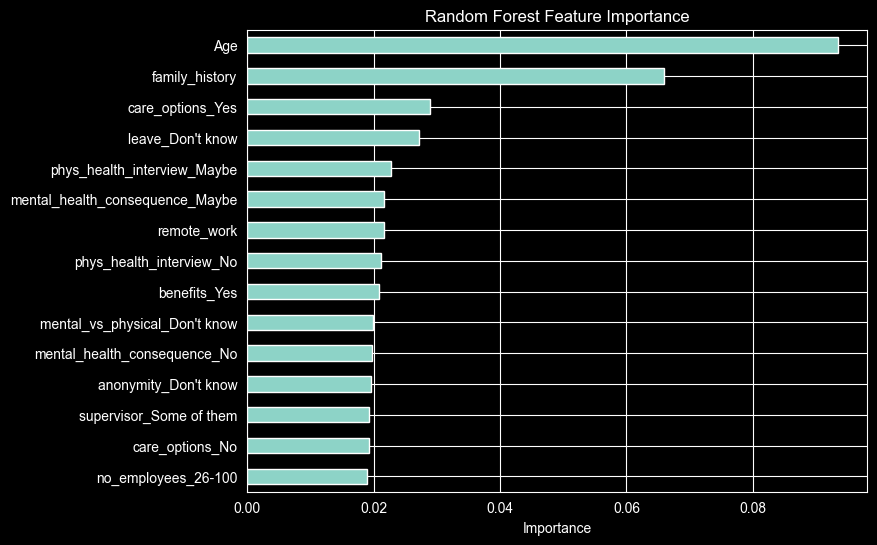

In [8]:
# Import evaluation metrics and visualization tools
# - classification_report: precision, recall, F1 per class
# - f1_score: overall F1 metrics
# - ConfusionMatrixDisplay: visualize prediction performance
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

# Import plotting library
import matplotlib.pyplot as plt

# Import pandas for handling feature importance
import pandas as pd

# Print detailed classification metrics (precision, recall, F1-score, support)
print(classification_report(y_test, y_pred_rf))

# Compute macro F1 score
# - treats all classes equally (good for imbalance insight)
macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")

# Compute weighted F1 score
# - accounts for class imbalance by weighting by class frequency
weighted_f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

# Print F1 scores
print("Random Forest Macro F1:", macro_f1_rf)
print("Random Forest Weighted F1:", weighted_f1_rf)

# Plot confusion matrix
# - shows correct vs incorrect predictions per class
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Extract feature importance from the trained Random Forest model
# - importance reflects contribution of each feature to predictions
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Display top 15 most important features
feature_importance.head(15)

# Plot top 15 features (horizontal bar chart)
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

# Add plot labels
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

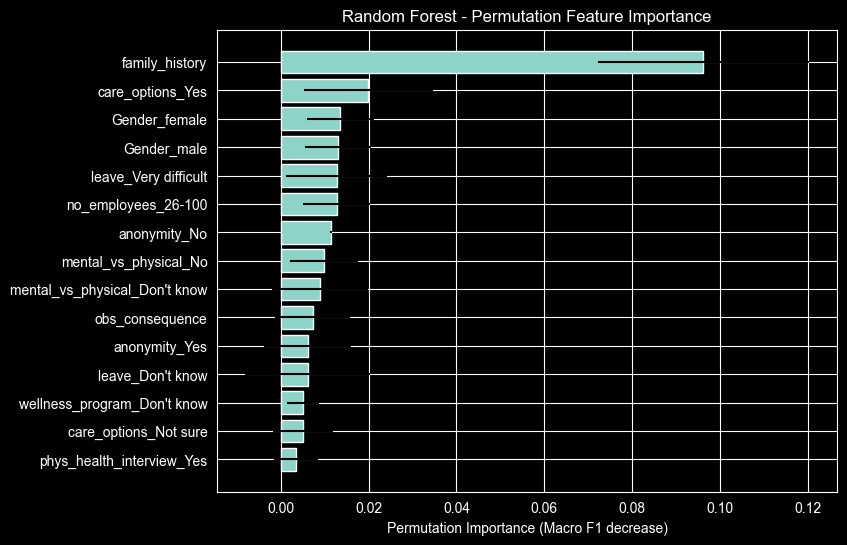

In [9]:
# Import permutation importance (model-agnostic feature importance)
# and plotting library
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Compute permutation importance on the test set
# - n_repeats: number of times each feature is shuffled (stability)
# - scoring="f1_macro": evaluates impact on macro F1 score
# - n_jobs=-1: use all CPU cores for faster computation
perm_importance = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

# Create a DataFrame with mean and standard deviation of importance
# - importance_mean: average decrease in performance when feature is shuffled
# - importance_std: variability across repetitions
perm_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

# Display top 15 most important features
perm_importance_df.head(15)

# Select top 15 features and sort for horizontal plotting
top_features = perm_importance_df.head(15).sort_values("importance_mean")

# Create horizontal bar plot
# - xerr shows variability (standard deviation)
plt.figure(figsize=(8,6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

# Label plot
plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("Random Forest - Permutation Feature Importance")

# Display plot
plt.show()

In [10]:
# Import XGBoost classifier (gradient boosting model)
from xgboost import XGBClassifier

# Initialize XGBoost model
# - objective="multi:softprob": outputs class probabilities for multiclass classification
# - num_class=3: number of target classes (e.g., 0, 1, 2)
# - n_estimators: number of boosting rounds (trees)
# - max_depth: maximum depth of each tree (controls model complexity)
# - learning_rate: step size shrinkage (lower = slower but more robust learning)
# - subsample: fraction of training samples used per tree (reduces overfitting)
# - colsample_bytree: fraction of features used per tree (adds randomness)
# - reg_alpha: L1 regularization (sparsity)
# - reg_lambda: L2 regularization (stability)
# - random_state: ensures reproducibility
# - eval_metric="mlogloss": evaluation metric for multiclass classification
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="mlogloss"
)

# Train the XGBoost model on the training data
xgb.fit(X_train, y_train)

# Generate predicted class labels for the test set
y_pred_xgb = xgb.predict(X_test)

# Generate predicted class probabilities for the test set
# (used for ROC-AUC, calibration, threshold analysis, etc.)
y_prob_xgb = xgb.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.46      0.42      0.44        43
           1       0.33      0.17      0.22        36
           2       0.70      0.82      0.76       120

    accuracy                           0.62       199
   macro avg       0.50      0.47      0.47       199
weighted avg       0.58      0.62      0.59       199

XGBoost Macro F1: 0.47232393443527315
XGBoost Weighted F1: 0.5907792546796541


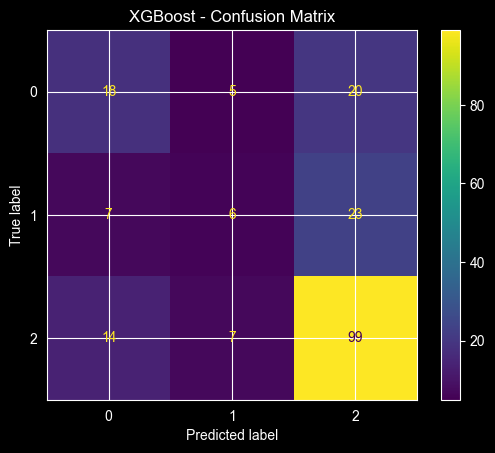

In [11]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred_xgb))

macro_f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
weighted_f1_xgb = f1_score(y_test, y_pred_xgb, average="weighted")

print("XGBoost Macro F1:", macro_f1_xgb)
print("XGBoost Weighted F1:", weighted_f1_xgb)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("XGBoost - Confusion Matrix")
plt.show()

family_history                   0.049200
care_options_Yes                 0.030592
anonymity_Yes                    0.023184
benefits_Yes                     0.021871
Gender_female                    0.021546
leave_Don't know                 0.020610
leave_Very difficult             0.020539
wellness_program_Yes             0.019286
leave_Somewhat difficult         0.019136
Gender_male                      0.019006
mental_health_consequence_Yes    0.018790
coworkers_Yes                    0.018413
no_employees_500-1000            0.018359
benefits_Don't know              0.018288
supervisor_No                    0.018001
dtype: float32


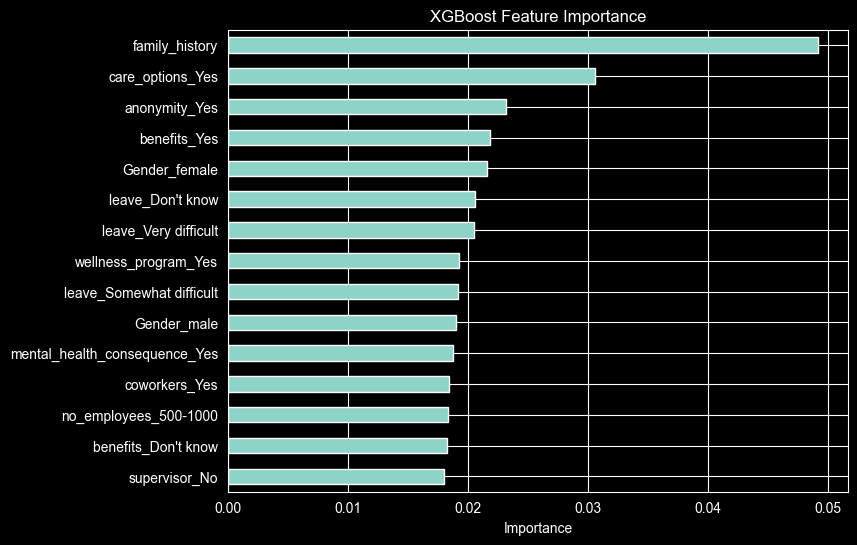

In [12]:
# Import pandas for handling feature importance as a Series
import pandas as pd

# Extract feature importance scores from the trained XGBoost model
# - feature_importances_ reflects the relative importance of each feature
# - index=X.columns aligns importance values with feature names
# - sort_values: rank features from most to least important
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Print the top 15 most important features
print(xgb_importance.head(15))

# Plot the top 15 features as a horizontal bar chart
# - sorted ascending for better visual ordering (largest at top)
# - figsize controls plot size
xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

# Add title and axis label
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")

# Display the plot
plt.show()

D:\Diana\Anul III\BachelorArbeit\WellBeingModelling\venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


                            feature  importance_mean  importance_std
2                    family_history         0.085522        0.021984
9                     Gender_female         0.035528        0.015787
0                               Age         0.022875        0.026015
27                     seek_help_No         0.022594        0.013901
22                 care_options_Yes         0.020717        0.014770
1                     self_employed         0.019866        0.011591
26             seek_help_Don't know         0.019246        0.011170
17              benefits_Don't know         0.018683        0.018459
32                 leave_Don't know         0.017823        0.017907
53         phys_health_interview_No         0.017108        0.011876
37  mental_health_consequence_Maybe         0.014003        0.014085
52      phys_health_interview_Maybe         0.013989        0.012806
41       phys_health_consequence_No         0.013146        0.018292
43                     coworkers_N

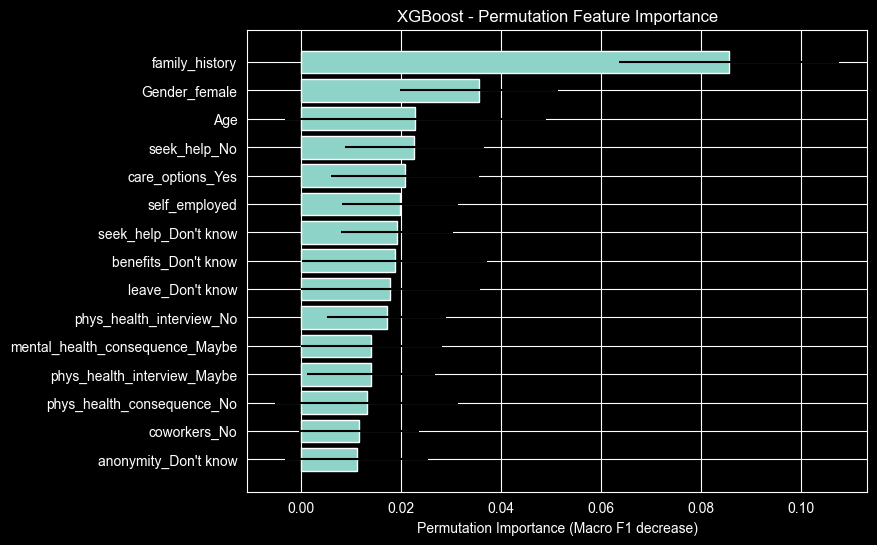

In [13]:
# Import permutation importance (model-agnostic feature importance method)
from sklearn.inspection import permutation_importance

# Compute permutation importance for the XGBoost model
# - Measures decrease in model performance when each feature is shuffled
# - n_repeats=20 improves stability of importance estimates
# - scoring="f1_macro" evaluates impact using macro F1 score
# - n_jobs=-1 uses all CPU cores for faster computation
perm_xgb = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

# Create a DataFrame with mean and standard deviation of importance scores
# - importance_mean: average decrease in performance
# - importance_std: variability across repetitions
perm_xgb_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)

# Print top 15 most important features
print(perm_xgb_df.head(15))

# Select top 15 features and sort for horizontal plotting
top_features = perm_xgb_df.head(15).sort_values("importance_mean")

# Plot permutation importance as horizontal bar chart
# - xerr displays variability (standard deviation)
plt.figure(figsize=(8, 6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

# Add axis label and title
plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("XGBoost - Permutation Feature Importance")

# Display plot
plt.show()

In [14]:
# Import Decision Tree classifier (interpretable tree-based model)
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree model
# - max_depth: limits tree depth to prevent overfitting
# - min_samples_split: minimum samples required to split a node (controls complexity)
# - min_samples_leaf: minimum samples in a leaf node (smooths predictions)
# - class_weight="balanced": adjusts for class imbalance
# - random_state: ensures reproducibility
tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

# Train the Decision Tree model on the training data
tree.fit(X_train, y_train)

# Generate predicted class labels for the test set
y_pred_tree = tree.predict(X_test)

# Generate predicted class probabilities for the test set
# (useful for ROC-AUC, calibration, and threshold-based analysis)
y_prob_tree = tree.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.34      0.67      0.45        43
           1       0.24      0.11      0.15        36
           2       0.78      0.63      0.70       120

    accuracy                           0.55       199
   macro avg       0.45      0.47      0.43       199
weighted avg       0.59      0.55      0.55       199

Decision Tree Macro F1: 0.43484307523983423
Decision Tree Weighted F1: 0.5476062150920676


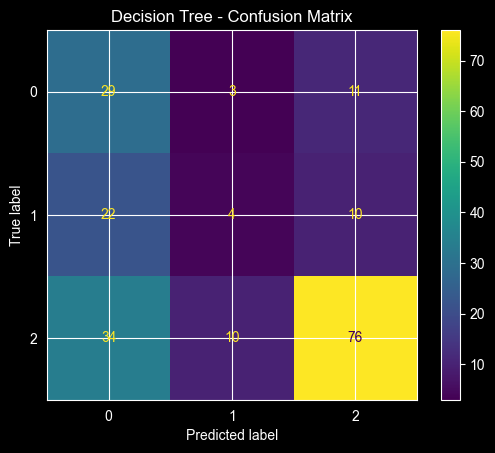

In [15]:
# Import evaluation metrics and visualization tools
# - classification_report: detailed metrics per class (precision, recall, F1)
# - f1_score: overall F1 metrics
# - ConfusionMatrixDisplay: visualizes prediction performance
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

# Import plotting library
import matplotlib.pyplot as plt

# Print classification report for Decision Tree predictions
# Includes precision, recall, F1-score, and support for each class
print(classification_report(y_test, y_pred_tree))

# Compute macro F1 score
# - treats all classes equally (useful for imbalanced datasets)
macro_f1_tree = f1_score(y_test, y_pred_tree, average="macro")

# Compute weighted F1 score
# - accounts for class imbalance by weighting by class frequency
weighted_f1_tree = f1_score(y_test, y_pred_tree, average="weighted")

# Print F1 scores
print("Decision Tree Macro F1:", macro_f1_tree)
print("Decision Tree Weighted F1:", weighted_f1_tree)

# Plot confusion matrix
# - shows correct vs incorrect predictions across classes
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

family_history                  0.200078
care_options_Yes                0.108507
phys_health_interview_Yes       0.076103
Age                             0.073980
no_employees_26-100             0.046861
leave_Very difficult            0.041253
mental_health_consequence_No    0.039387
mental_vs_physical_No           0.039199
obs_consequence                 0.036161
remote_work                     0.032559
wellness_program_Yes            0.029423
phys_health_interview_No        0.028438
care_options_No                 0.026800
anonymity_Don't know            0.022384
benefits_Yes                    0.021246
dtype: float64


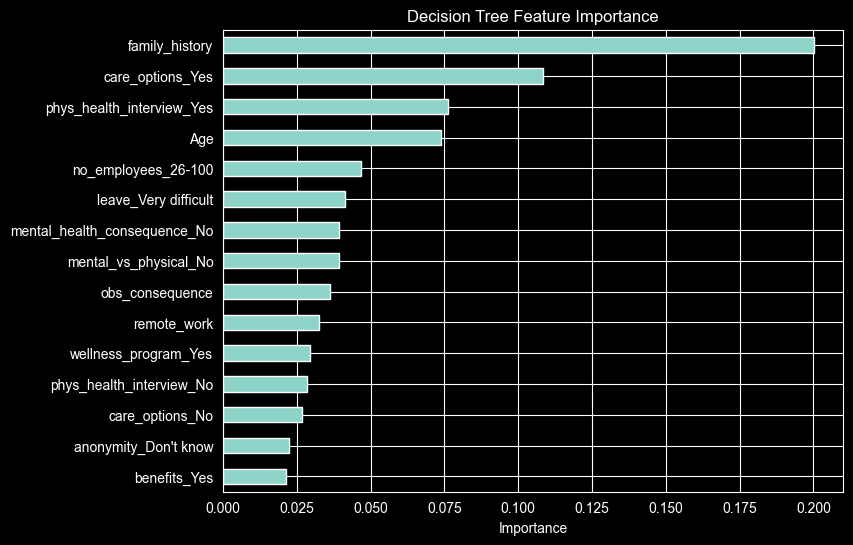

In [16]:
# Import pandas to handle feature importance as a Series
import pandas as pd

# Extract feature importance from the trained Decision Tree model
# - feature_importances_ reflects how much each feature contributes to splits
# - index=X.columns assigns feature names
# - sort_values ranks features from most to least important
tree_importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Print top 15 most important features
print(tree_importance.head(15))

# Plot top 15 features as a horizontal bar chart
# - sorted ascending for better visual ordering (largest at top)
tree_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

# Add plot title and axis label
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")

# Display the plot
plt.show()

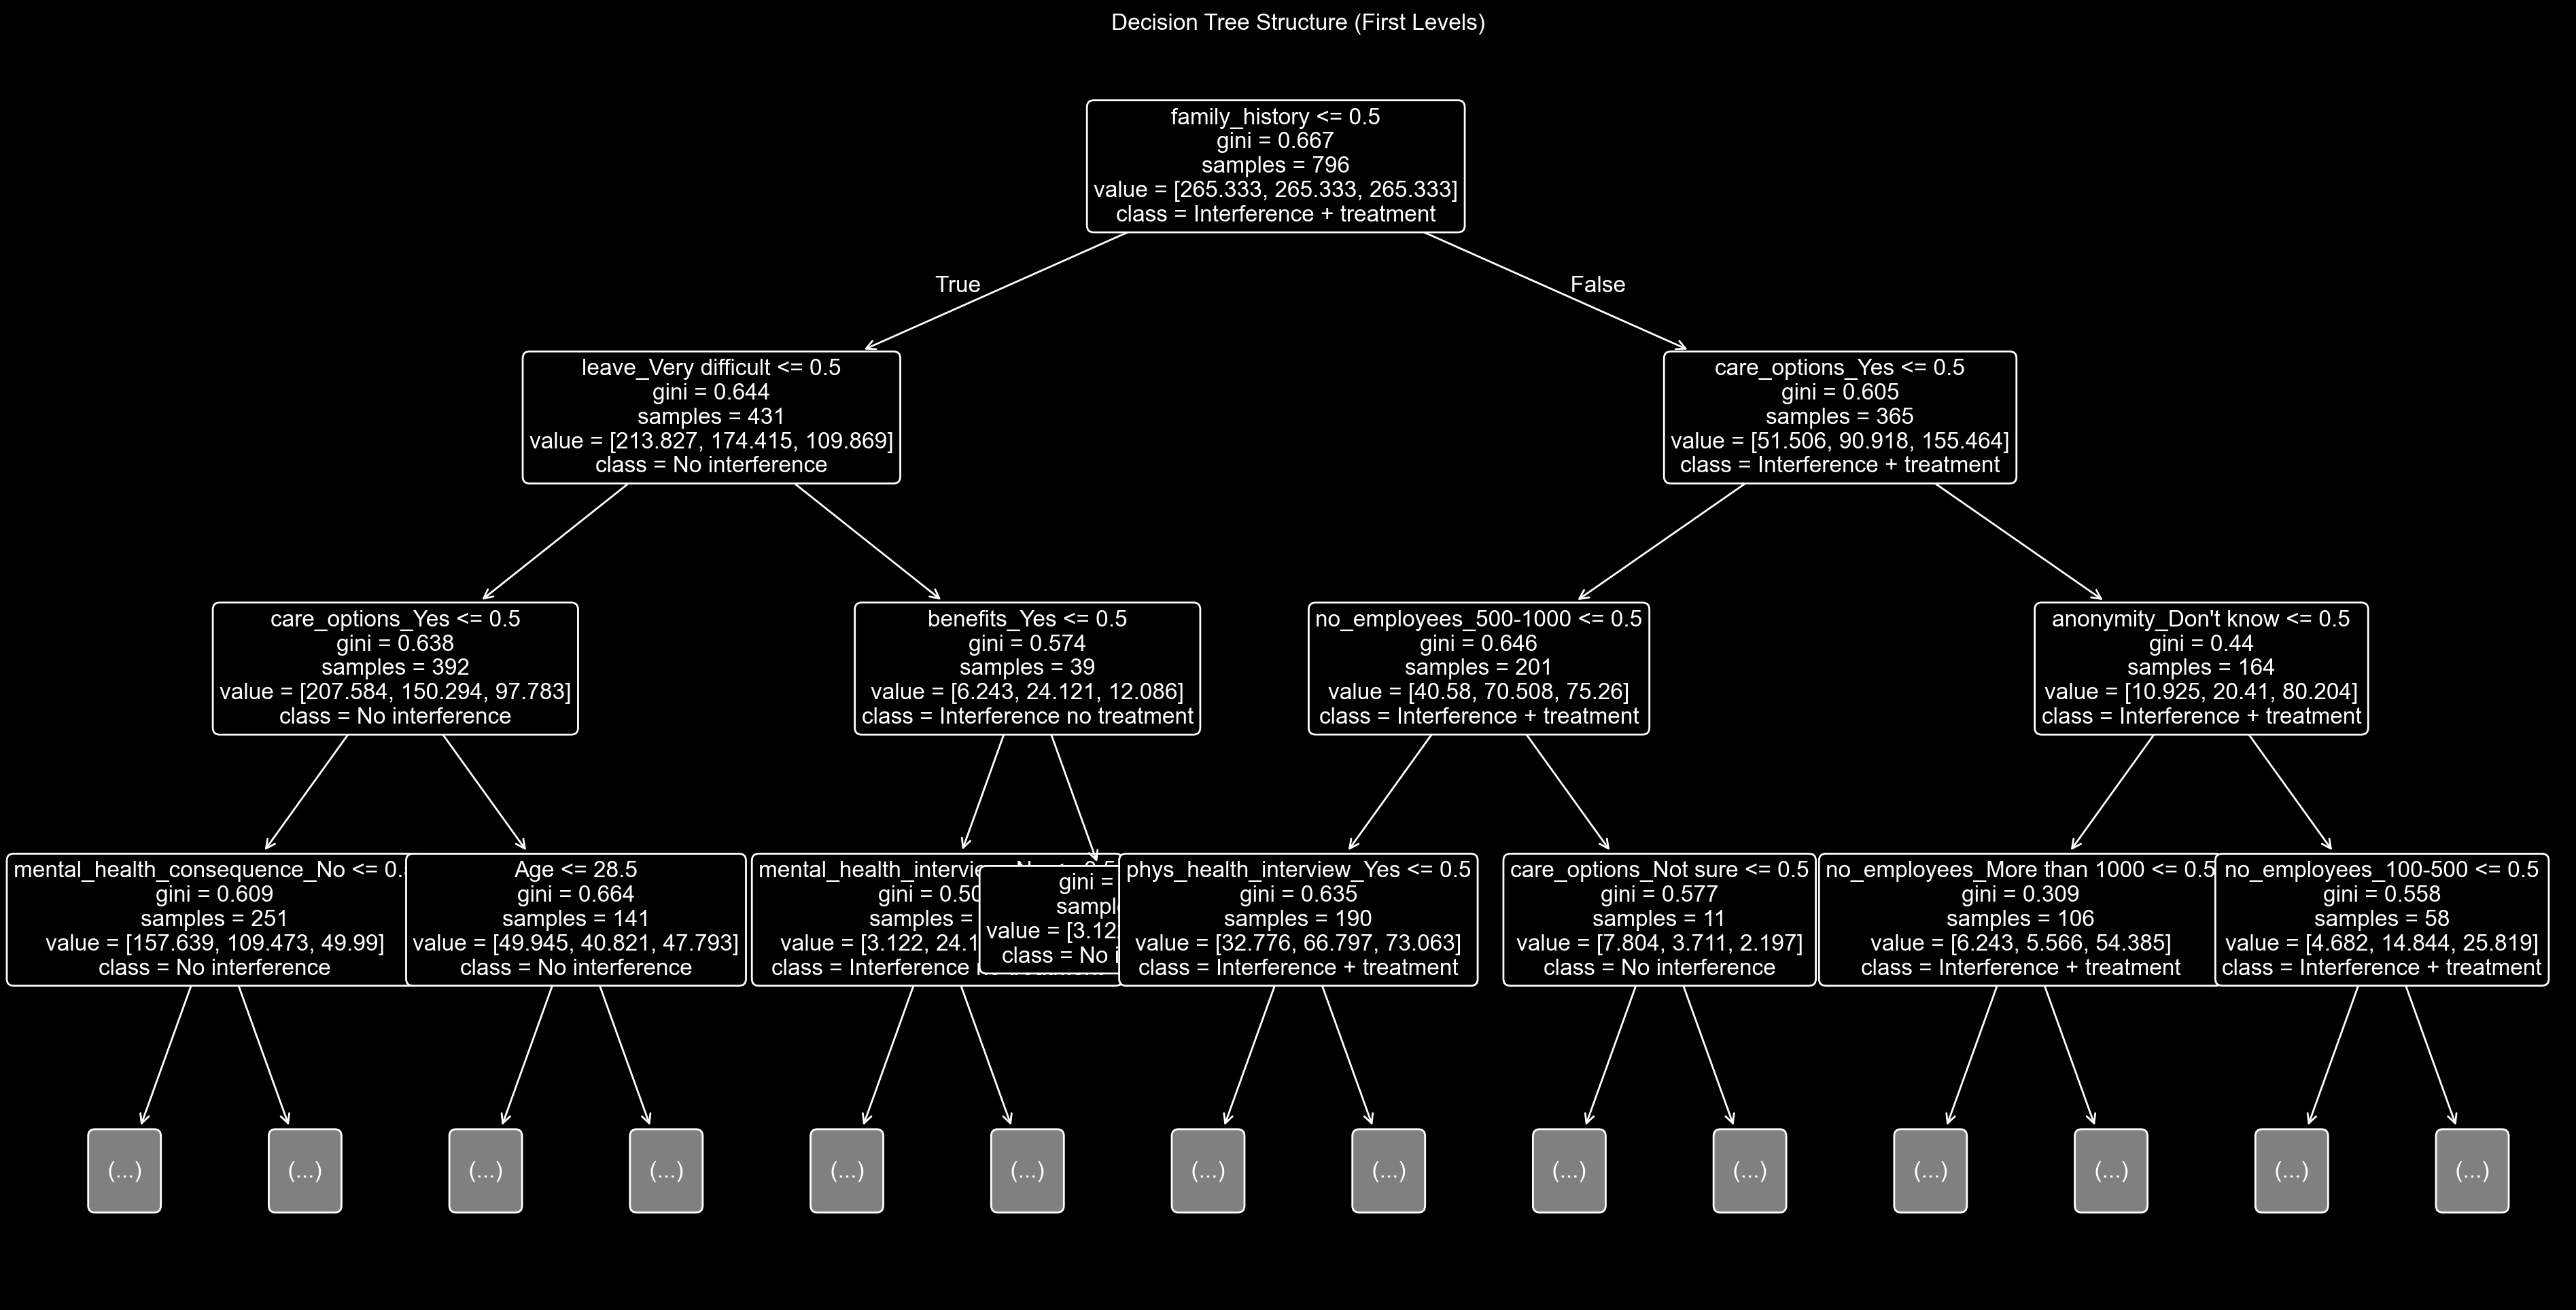

In [17]:
# Import function to visualize the decision tree structure
from sklearn.tree import plot_tree

# Create a large figure for better readability
# - figsize controls size
# - dpi increases resolution (important for thesis-quality figures)
plt.figure(figsize=(24,12), dpi=200)

# Plot the trained Decision Tree
# - feature_names: names of input variables used in splits
# - class_names: labels for target classes (used in leaf nodes)
# - rounded=True: improves visual aesthetics
# - max_depth=3: only show top levels for interpretability
# - fontsize: controls text size in the plot
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No interference","Interference no treatment","Interference + treatment"],
    rounded=True,
    max_depth=3,
    fontsize=12
)

# Add title to the visualization
plt.title("Decision Tree Structure (First Levels)")

# Display the plot
plt.show()

In [18]:
results = pd.DataFrame([
    {"Model": "Logistic Regression", "Macro F1": macro_f1, "Weighted F1": weighted_f1},
    {"Model": "Decision Tree", "Macro F1": macro_f1_tree, "Weighted F1": weighted_f1_tree},
    {"Model": "Random Forest", "Macro F1": macro_f1_rf, "Weighted F1": weighted_f1_rf},
    {"Model": "XGBoost", "Macro F1": macro_f1_xgb, "Weighted F1": weighted_f1_xgb}
])

print(results)

                 Model  Macro F1  Weighted F1
0  Logistic Regression  0.522756     0.586191
1        Decision Tree  0.434843     0.547606
2        Random Forest  0.500554     0.615048
3              XGBoost  0.472324     0.590779
